# Bregman Divergences and Mirror Descent

The **Bregman divergence** generated by a strictly convex differentiable function $\phi : \Omega \to \mathbb{R}$ is
$$
D_\phi(x, y) = \phi(x) - \phi(y) - \langle \nabla\phi(y),\, x - y \rangle.
$$
Geometrically, $D_\phi(x,y)$ measures how much the graph of $\phi$ at $x$ exceeds its first-order Taylor expansion from $y$. It is always **non-negative** (by convexity) and vanishes if and only if $x = y$, but it is generally **not symmetric**.

The **$\alpha$-divergence** family is generated by
$$
\phi_\alpha(s) = \frac{s^\alpha - \alpha(s-1) - 1}{\alpha(\alpha-1)}, \qquad \alpha \in \mathbb{R} \setminus \{0, 1\},
$$
with limiting cases $\phi_0(s) = -\log s + s - 1$ and $\phi_1(s) = s\log s - s + 1$. Special values recover well-known divergences:
- $\alpha = 2$: $\frac{1}{2}(x-y)^2$ (squared Euclidean, up to a constant),
- $\alpha \to 1$: Kullback–Leibler (KL) divergence $\sum x_i \log(x_i/y_i)$,
- $\alpha \to 0$: reverse KL $\sum y_i \log(y_i/x_i)$.

**Mirror descent** replaces the Euclidean gradient step with a Bregman proximal update. Given a loss $f$, the mirror descent iteration is:
$$
x_{k+1} = \nabla\phi^*\!\bigl(\nabla\phi(x_k) - \tau\,\nabla f(x_k)\bigr),
$$
where $\phi^*$ is the convex conjugate of $\phi$. Equivalently, the continuous-time flow satisfies
$$
\dot{x} = -\bigl[\nabla^2\phi(x)\bigr]^{-1}\nabla f(x),
$$
which is a gradient flow on the **Hessian Riemannian manifold** defined by $\phi$. The choice of $\phi$ encodes prior geometric knowledge: $\phi_\alpha$ with small $\alpha$ strongly penalizes near-zero iterates (logarithmic barrier), making mirror descent natural for **constrained optimization** on the positive orthant.

This notebook visualizes the $\alpha$-divergence family, studies mirror-descent trajectories for a simple linear regression problem, and explores how the choice of $\phi$ shapes the optimization path.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

plt.rcParams["figure.dpi"] = 120

## The $\alpha$-divergence generating functions

The family $\phi_\alpha$ is parameterized continuously by $\alpha$. All members satisfy $\phi_\alpha(1) = 0$ and $\phi_\alpha'(1) = 0$, so $s = 1$ is the unique minimum and $D_{\phi_\alpha}(x,1) = \phi_\alpha(x) \geq 0$.

The curvature (Hessian) $\phi_\alpha''(s) = s^{\alpha-2}$ ranges from steeply curved near zero (small $\alpha$) to uniformly curved ($\alpha = 2$, quadratic). This anisotropy is what makes Bregman-based algorithms geometry-aware.

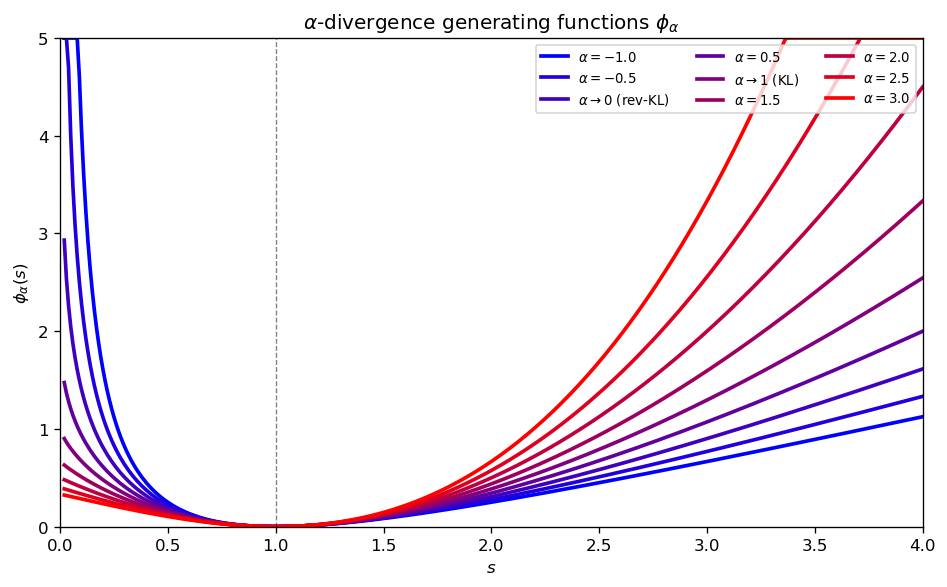

In [2]:
def phi_alpha(s, a):
    """alpha-divergence generating function (scalar or array)."""
    s = np.asarray(s, dtype=float)
    # handle limiting cases
    if abs(a) < 1e-8:        # alpha -> 0: -log s + s - 1
        return -np.log(np.maximum(s, 1e-10)) + s - 1
    if abs(a - 1) < 1e-8:    # alpha -> 1: s log s - s + 1
        return s * np.log(np.maximum(s, 1e-10)) - s + 1
    return (np.maximum(s, 1e-10)**a - a * (s - 1) - 1) / (a * (a - 1))


x = np.linspace(0.02, 4.0, 400)
alpha_list = [-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

fig, ax = plt.subplots(figsize=(8, 5))
for j, a in enumerate(alpha_list):
    sv = j / (len(alpha_list) - 1)
    y = np.clip(phi_alpha(x, a), 0, 5)
    lbl = (f"$\\alpha={a:.1f}$" if abs(a) > 1e-5 and abs(a - 1) > 1e-5
           else (r"$\alpha\to 0$ (rev-KL)" if abs(a) < 1e-5 else r"$\alpha\to 1$ (KL)"))
    ax.plot(x, y, color=(sv, 0.0, 1 - sv), lw=2.2, label=lbl)

ax.axvline(1, color="k", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("$s$")
ax.set_ylabel(r"$\phi_\alpha(s)$")
ax.set_title(r"$\alpha$-divergence generating functions $\phi_\alpha$")
ax.set_xlim(0, 4); ax.set_ylim(0, 5)
ax.legend(fontsize=8, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

## The Bregman divergence on the simplex

For $x, y \in \mathbb{R}_{>0}^d$, the Bregman divergence is
$$
D_{\phi_\alpha}(x, y) = \sum_{i=1}^d \bigl[\phi_\alpha(x_i) - \phi_\alpha(y_i) - \phi_\alpha'(y_i)(x_i - y_i)\bigr].
$$

In the $d = 2$ case, the level sets of $D_{\phi_\alpha}(\cdot, y)$ for fixed $y = (0.3, 0.7)$ are plotted below. For $\alpha = 2$ they are ellipses (Euclidean); for $\alpha \to 1$ (KL) they are highly asymmetric, heavily penalizing entries close to zero.

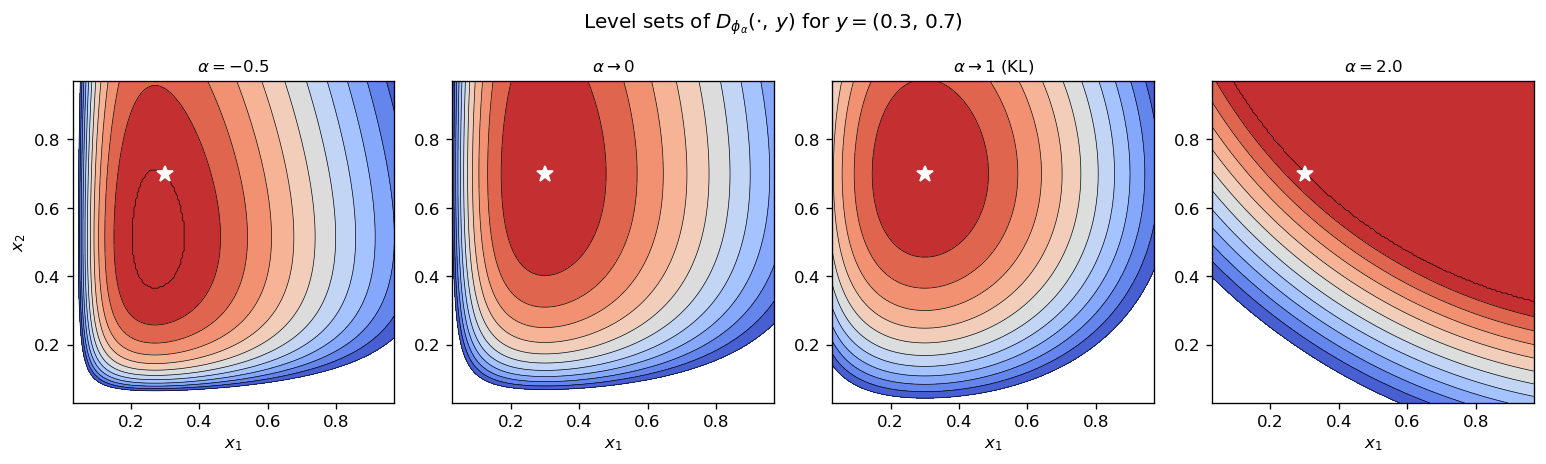

In [3]:
def bregman_div(x1, x2, y1, y2, a):
    """Bregman divergence D_phi(x, y) in 2D."""
    px = phi_alpha(x1, a) + phi_alpha(x2, a)
    py = phi_alpha(y1, a) + phi_alpha(y2, a)
    # gradient phi'(y_i) = y_i^{alpha-1} (for alpha != 0,1 approx)
    if abs(a) < 1e-8:
        gpy = np.array([-1/y1 + 1, -1/y2 + 1])
    elif abs(a - 1) < 1e-8:
        gpy = np.array([np.log(y1), np.log(y2)])
    else:
        gpy = np.array([y1**(a - 1) / (a - 1), y2**(a - 1) / (a - 1)])
    ip = gpy[0] * (x1 - y1) + gpy[1] * (x2 - y2)
    return px - py - ip


r = 0.97
ng = 200
g1 = np.linspace(0.03, r, ng)
g2 = np.linspace(0.03, r, ng)
G1, G2 = np.meshgrid(g1, g2)

y_ref = (0.3, 0.7)
alphas_plot = [-0.5, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, a in zip(axes, alphas_plot):
    D = bregman_div(G1, G2, *y_ref, a)
    D = np.maximum(D - bregman_div(y_ref[0], y_ref[1], *y_ref, a), 0.0)
    levels = np.linspace(0, np.percentile(D, 90), 12)
    ax.contourf(g1, g2, D, levels=levels, cmap="coolwarm_r")
    ax.contour(g1, g2, D, levels=levels, colors="k", linewidths=0.4)
    ax.plot(*y_ref, "w*", ms=10)
    lbl = (f"$\\alpha={a}$" if abs(a) > 1e-5 and abs(a - 1) > 1e-5
           else (r"$\alpha\to 0$" if abs(a) < 1e-5 else r"$\alpha\to 1$ (KL)"))
    ax.set_title(lbl, fontsize=10)
    ax.set_aspect("equal"); ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$" if ax is axes[0] else "")
fig.suptitle(r"Level sets of $D_{\phi_\alpha}(\cdot,\,y)$ for $y=(0.3,\,0.7)$", y=1.02)
plt.tight_layout()
plt.show()

## Mirror descent on a 2D linear problem

Consider the constrained least-squares problem:
$$
\min_{x \in \mathbb{R}_{>0}^2} f(x) = \tfrac{1}{2}\|Ax - b\|^2,
$$
with $A = [1.2,\; 1]$ and $b = 1$. The minimizer on the positive orthant lies at a point on the constraint set $\{x \geq 0\}$.

The continuous **mirror flow** with potential $\phi_\alpha$ evolves as:
$$
\frac{d}{dt}\nabla\phi(x(t)) = -\nabla f(x(t)),
$$
which in component form gives
$$
\dot{x}_i = -\frac{\partial_i f(x)}{\phi_\alpha''(x_i)} = -x_i^{2-\alpha}\,\partial_i f(x).
$$

Different $\alpha$ produce qualitatively different trajectories from the same starting point.

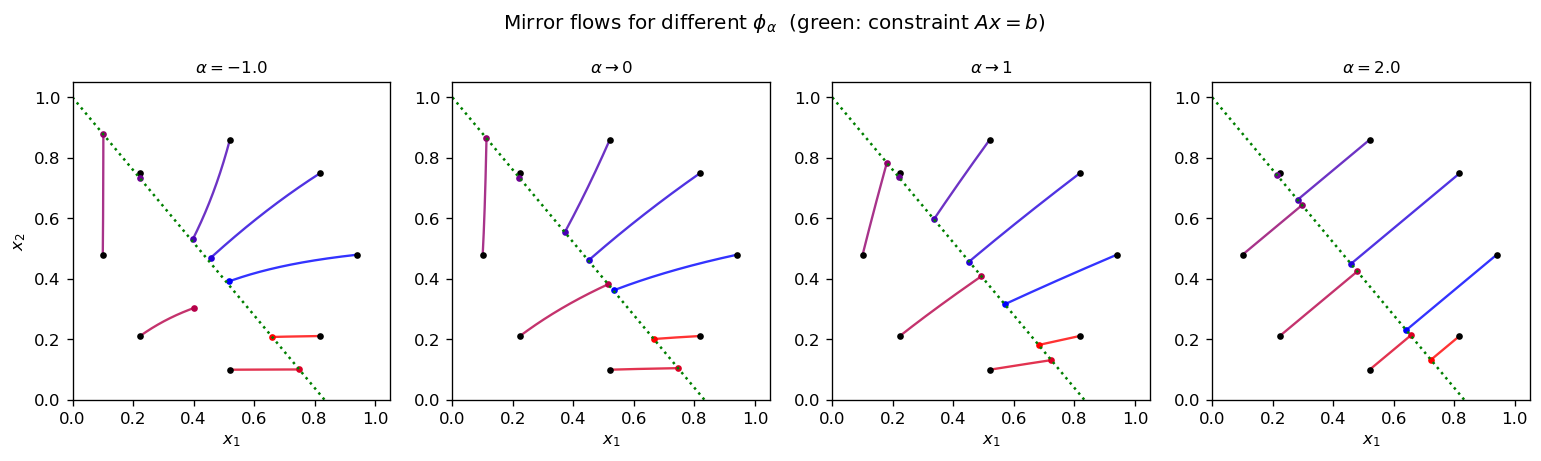

In [4]:
A = np.array([1.2, 1.0])
b = 1.0

def grad_f(x):
    return A * (A @ x - b)


def mirror_flow(x0, alpha, tau=0.005, niter=3000, clip_norm=0.05):
    """Discrete mirror flow trajectory."""
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    for _ in range(niter):
        step = (x ** (2 - alpha)) * grad_f(x)
        # cap step size for stability
        norm = np.linalg.norm(step)
        if norm > clip_norm:
            step = clip_norm * step / norm
        x = np.maximum(1e-5, x - tau * step)
        traj.append(x.copy())
    return np.array(traj)


# Use 8 starting points arranged in a circle around (0.5, 0.5)
n_starts = 8
angles = np.linspace(0, 2 * np.pi, n_starts, endpoint=False)
starts = [(max(0.06, 0.52 + 0.42 * np.cos(a)),
           max(0.06, 0.48 + 0.38 * np.sin(a))) for a in angles]

alpha_flows = [-1.0, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
x_sol = np.array([b / (A @ A) * A[0], b / (A @ A) * A[1]])   # unconstrained min

for ax, a in zip(axes, alpha_flows):
    for j, x0 in enumerate(starts):
        sv = j / (n_starts - 1)
        traj = mirror_flow(x0, a)
        ax.plot(traj[:, 0], traj[:, 1], lw=1.4, color=(sv, 0, 1 - sv), alpha=0.8)
        ax.plot(*x0, "k.", ms=6)
        ax.plot(*traj[-1], ".", ms=6, color=(sv, 0, 1 - sv))
    # constraint line A·x = b
    t_line = np.linspace(0, b / A[0], 100)
    ax.plot(t_line, (b - A[0] * t_line) / A[1], "g:", lw=1.5)
    ax.set_aspect("equal")
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$" if ax is axes[0] else "")
    lbl = (f"$\\alpha={a}$" if abs(a) > 1e-5 and abs(a - 1) > 1e-5
           else (r"$\alpha\to 0$" if abs(a) < 1e-5 else r"$\alpha\to 1$"))
    ax.set_title(lbl, fontsize=10)
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
fig.suptitle(r"Mirror flows for different $\phi_\alpha$  (green: constraint $Ax=b$)", y=1.02)
plt.tight_layout()
plt.show()

## Entropic mirror descent on the simplex

For a linear objective $\langle c,x\rangle$ on the probability simplex, the entropy mirror map gives the multiplicative update
$$x_i^{k+1}\propto x_i^k e^{-\eta c_i}.$$
This second experiment isolates that geometry from the preceding continuous trajectories.

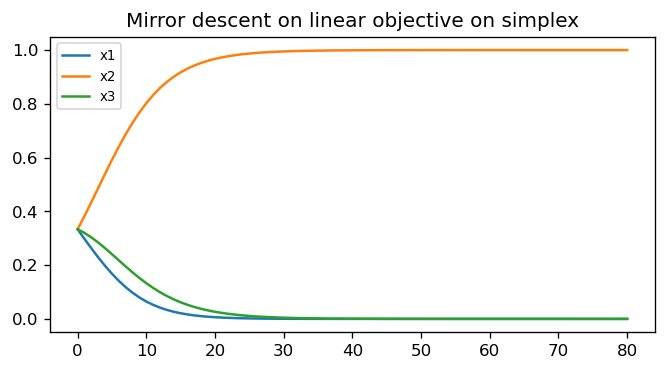

In [5]:
# Mirror descent on a linear objective over simplex (minimal add-on)
c_lin = np.array([1.1, -0.3, 0.7])
x = np.array([1/3, 1/3, 1/3], float)
eta = 0.18
traj_lin = [x.copy()]
for _ in range(80):
    x = x * np.exp(-eta * c_lin)
    x /= x.sum()
    traj_lin.append(x.copy())
traj_lin = np.array(traj_lin)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(traj_lin[:,0], label='x1'); ax.plot(traj_lin[:,1], label='x2'); ax.plot(traj_lin[:,2], label='x3')
ax.set_title('Mirror descent on linear objective on simplex')
ax.legend(fontsize=8)
plt.show()

## Interactive: single mirror-flow trajectory

Fix a starting point and explore how changing $\alpha$ alters the convergence path. The green dotted line is the level set $Ax = b$ that the unconstrained minimizer lies on.

## Convergence speed comparison

We measure the residual $f(x_k) = \frac{1}{2}\|Ax_k - b\|^2$ across iterations for several $\alpha$ values, starting from the same point. Different potentials give different convergence speeds and trajectories — $\alpha = 2$ (Euclidean gradient descent) is not always the fastest, especially when the problem geometry favors a different metric.

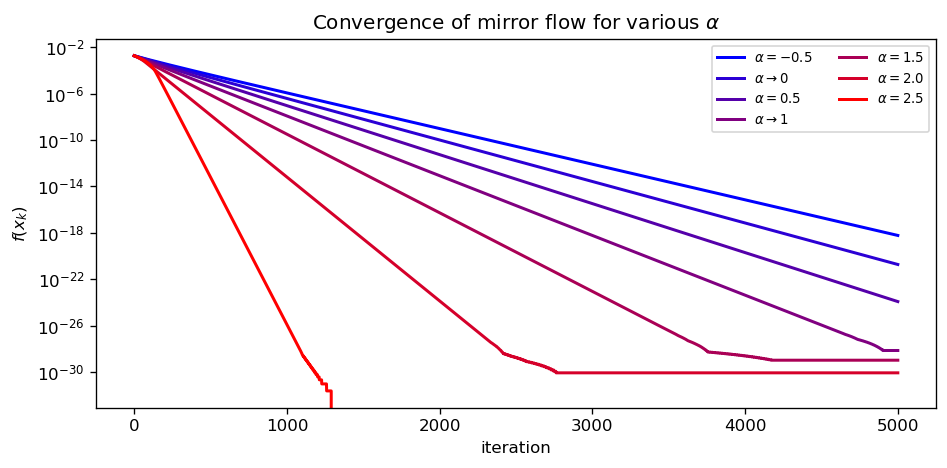

In [6]:
x0_fixed = (0.8, 0.1)
niter_conv = 5000

fig, ax = plt.subplots(figsize=(8, 4))
for j, a in enumerate([-0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5]):
    traj = mirror_flow(x0_fixed, a, tau=0.005, niter=niter_conv)
    loss = np.array([0.5 * (A @ xi - b)**2 for xi in traj])
    sv = j / 6
    lbl = (f"$\\alpha={a}$" if abs(a) > 1e-5 and abs(a - 1) > 1e-5
           else (r"$\alpha\to 0$" if abs(a) < 1e-5 else r"$\alpha\to 1$"))
    ax.semilogy(loss, lw=1.8, color=(sv, 0, 1 - sv), label=lbl)

ax.set_xlabel("iteration")
ax.set_ylabel(r"$f(x_k)$")
ax.set_title(r"Convergence of mirror flow for various $\alpha$")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Bibliographical resources

- Bregman, L. M. (1967). The relaxation method of finding the common point of convex sets and its application to the solution of problems in convex programming. *USSR Computational Mathematics and Mathematical Physics*, 7(3), 200–217.
- Nemirovskii, A. and Yudin, D. (1983). *Problem Complexity and Method Efficiency in Optimization*. Wiley.
- Beck, A. and Teboulle, M. (2003). Mirror descent and nonlinear projected subgradient methods for convex optimization. *Operations Research Letters*, 31(3), 167–175.
- Amari, S.-I. (2016). *Information Geometry and its Applications*. Springer.
- Bubeck, S. (2015). Convex optimization: Algorithms and complexity. *Foundations and Trends in Machine Learning*, 8(3–4), 231–357.
- Gunasekar, S. et al. (2021). Mirror descent view for neural network training. *ICML*.